In [ ]:
import pandas as pd
from narwhals.stable.v2 import exclude

pd.options.display.max_columns = None
df = pd.read_csv("data/student_placement_prediction_dataset_2026.csv")

In [21]:
df.head(10)

,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,aptitude_score,communication_skill_score,logical_reasoning_score,hackathons_participated,github_repos,linkedin_connections,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,81.707722,57.707166,59.070073,4,1,184,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,2,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,63.116715,59.197085,78.976419,0,2,539,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,3,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,48.658753,92.104885,80.603331,0,2,568,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,4,24,Male,6.68,CSE,Tier 1,0,2,2,79.359084,66.376653,83.411798,64.187246,1,1,550,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,5,20,Female,8.43,IT,Tier 3,1,4,3,65.018573,61.274985,88.956331,56.163678,1,4,833,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16
5,6,22,Male,7.44,CSE,Tier 2,1,5,1,49.758865,45.252593,51.881728,69.984592,3,8,77,66.138578,82.038139,0,54.150818,69.210022,No,9.1,3.4,Placed,11.78
6,7,22,Male,7.54,CSE,Tier 3,0,2,2,68.816160,63.787196,79.969910,76.546475,0,2,154,56.207496,72.267945,1,79.323137,26.179746,No,8.9,3.1,Not Placed,0.00
7,8,24,Female,6.86,Civil,Tier 3,3,4,2,87.471971,56.962395,58.138781,66.579454,2,8,98,89.189601,79.128528,1,23.394036,36.903695,Yes,8.8,1.6,Not Placed,0.00
8,9,19,Male,8.52,Mechanical,Tier 2,2,5,0,100.000000,93.987115,75.165144,87.737986,0,7,269,64.035703,89.884948,0,68.598878,42.647145,No,8.5,4.2,Placed,16.33
9,10,20,Female,8.07,Civil,Tier 2,2,2,2,93.421972,71.379374,57.215196,58.628985,0,6,747,72.217117,88.901107,0,86.199176,1.371853,No,5.9,4.5,Placed,16.17


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   student_id                 100000 non-null  int64  
 1   age                        100000 non-null  int64  
 2   gender                     100000 non-null  object 
 3   cgpa                       100000 non-null  float64
 4   branch                     100000 non-null  object 
 5   college_tier               100000 non-null  object 
 6   internships_count          100000 non-null  int64  
 7   projects_count             100000 non-null  int64  
 8   certifications_count       100000 non-null  int64  
 9   coding_skill_score         100000 non-null  float64
 10  aptitude_score             100000 non-null  float64
 11  communication_skill_score  100000 non-null  float64
 12  logical_reasoning_score    100000 non-null  float64
 13  hackathons_participated    100

student_id — ID студента

age — Возраст

gender — Пол

cgpa — CGPA (средний балл)

branch — Специальность / Направление

college_tier — Уровень колледжа (Tier)

internships_count — Количество стажировок

projects_count — Количество проектов

certifications_count — Количество сертификатов

coding_skill_score — Уровень навыков программирования

aptitude_score — Оценка способностей (aptitude test)

communication_skill_score — Навыки коммуникации

logical_reasoning_score — Логическое мышление

hackathons_participated — Участие в хакатонах

github_repos — Репозитории на GitHub

linkedin_connections — Связи на LinkedIn

mock_interview_score — Оценка за пробное собеседование

attendance_percentage — Процент посещаемости

backlogs — Количество долгов / пересдач

extracurricular_score — Внеучебная активность

leadership_score — Лидерские качества

volunteer_experience — Волонтёрский опыт

sleep_hours — Часы сна в сутки

study_hours_per_day — Часы учёбы в день

placement_status — Статус трудоустройства

salary_package_lpa — Зарплата (в LPA — lakhs per annum)

*Для классификации:* placement_status - трудоустроился или нет

*Для регрессии:* salary_package_lpa - зарплата

In [23]:
# КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['gender', 'branch', 'college_tier', 'volunteer_experience', 'placement_status']

le = LabelEncoder()

for col in categorical_cols:
    df[col + '_encoded'] = le.fit_transform(df[col])

print(df[['placement_status', 'placement_status_encoded']].head())

  placement_status  placement_status_encoded
0       Not Placed                         0
1       Not Placed                         0
2           Placed                         1
3       Not Placed                         0
4           Placed                         1


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   student_id                    100000 non-null  int64  
 1   age                           100000 non-null  int64  
 2   gender                        100000 non-null  object 
 3   cgpa                          100000 non-null  float64
 4   branch                        100000 non-null  object 
 5   college_tier                  100000 non-null  object 
 6   internships_count             100000 non-null  int64  
 7   projects_count                100000 non-null  int64  
 8   certifications_count          100000 non-null  int64  
 9   coding_skill_score            100000 non-null  float64
 10  aptitude_score                100000 non-null  float64
 11  communication_skill_score     100000 non-null  float64
 12  logical_reasoning_score       100000 non-null

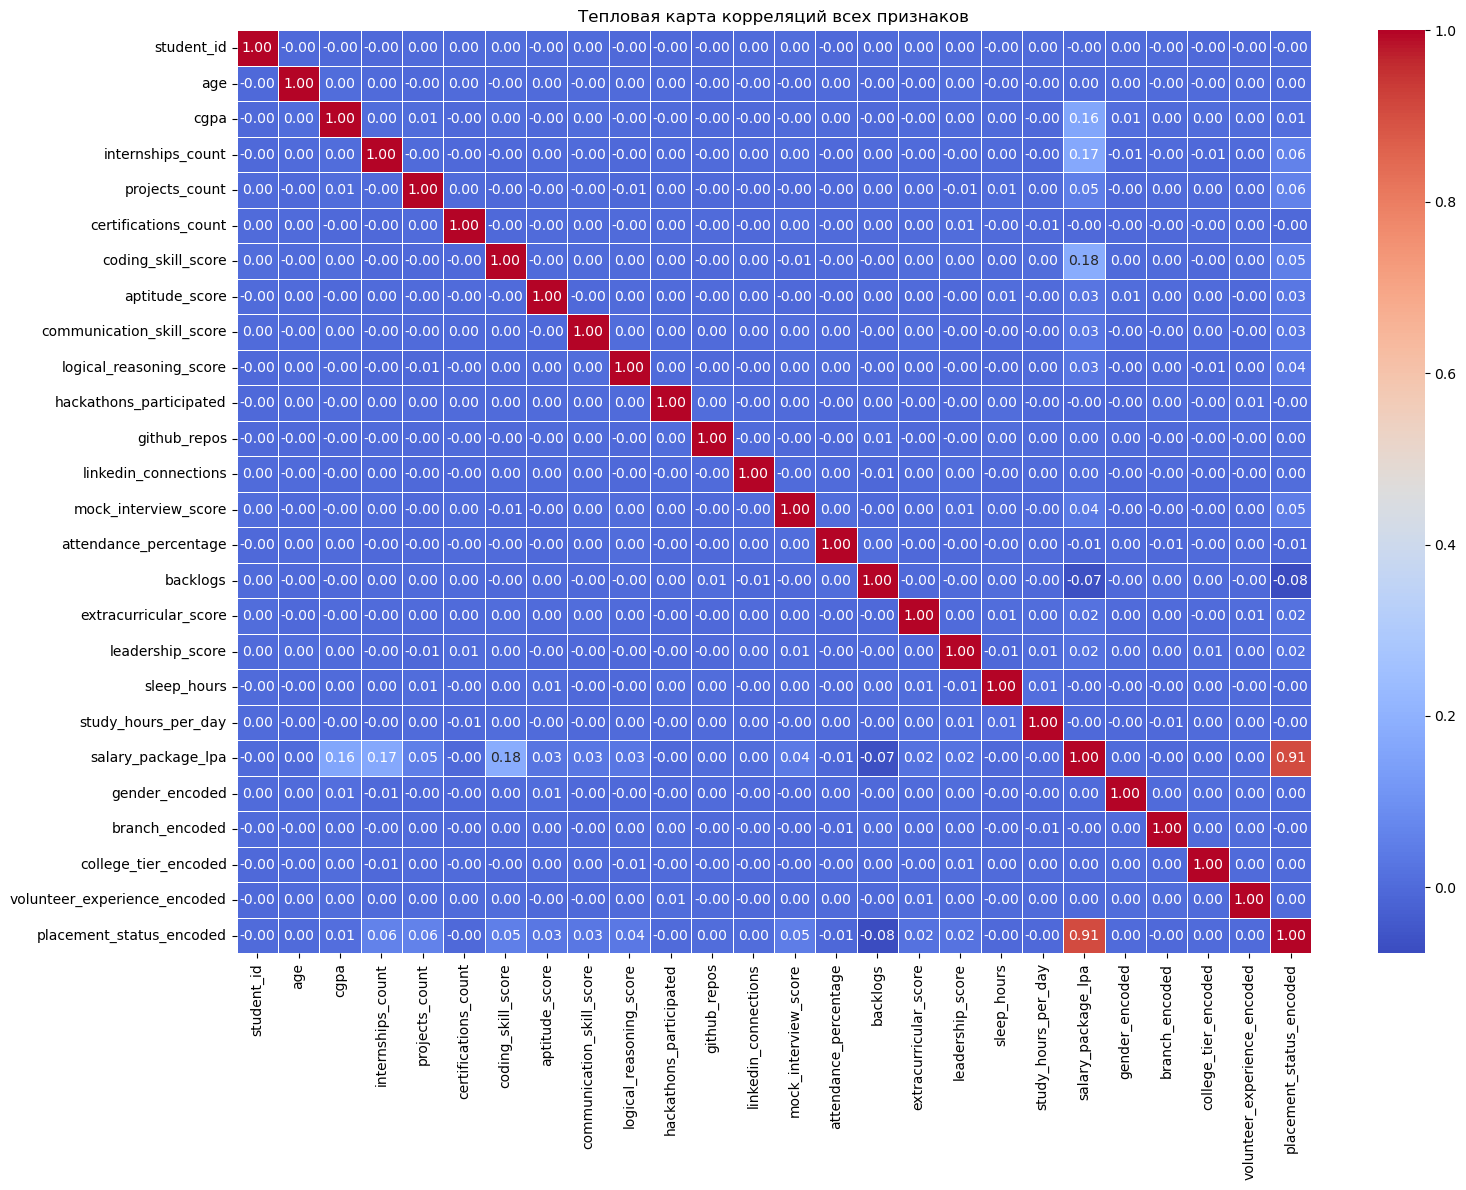

In [25]:
# КОРРЕЛЯЦИОННАЯ МАТРИЦА И ТЕПЛОВАЯ КАРТА
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = df.select_dtypes(include=['int32', 'int64', 'float64']).copy()

plt.figure(figsize=(16, 12))
corr_matrix = numeric_df.corr(method='spearman') # можно добавить method='spearman'

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Тепловая карта корреляций всех признаков')
plt.tight_layout()
plt.show()

Самые заметные корреляции с placement_status_encoded (трудоустройство):

- salary_package_lpa → +0.98
- (это логично: если человек устроился — у него есть зарплата, если нет — 0)
- internships_count → +0.05 - Количество стажировок
- projects_count → +0.06 - Количество проектов
- coding_skill_score → +0.05 - Навыки программирования
- mock_interview_score → +0.04 - Результаты мок-интервью
- cgpa → +0.06 - Средний балл за весь период обучения
- aptitude_score → +0.03 - Средний рейтинг за тест
- backlogs → -0.08 (чем больше долгов — тем хуже шансы на трудоустройство)


Корреляции с salary_package_lpa (зарплата):

- internships_count → +0.11 - Количества стажировок
- coding_skill_score → +0.11 - Навыки программирования
- cgpa → +0.08 - Средний балл за весь период обучения
- projects_count → +0.06 - Количества проектов
- mock_interview_score → +0.04 - Результаты интервью


Корреляция входных признаков с трудоустройством (по убыванию):
internships_count               0.063489
projects_count                  0.060964
coding_skill_score              0.050773
mock_interview_score            0.046058
logical_reasoning_score         0.036332
communication_skill_score       0.032242
aptitude_score                  0.031690
leadership_score                0.022170
extracurricular_score           0.020100
cgpa                            0.012067
github_repos                    0.004807
linkedin_connections            0.003223
college_tier_encoded            0.002005
gender_encoded                  0.001244
volunteer_experience_encoded    0.001240
hackathons_participated         0.001236
age                             0.000858
student_id                     -0.000821
study_hours_per_day            -0.001426
certifications_count           -0.003806
branch_encoded                 -0.004320
sleep_hours                    -0.004692
attendance_percentage          -0.0

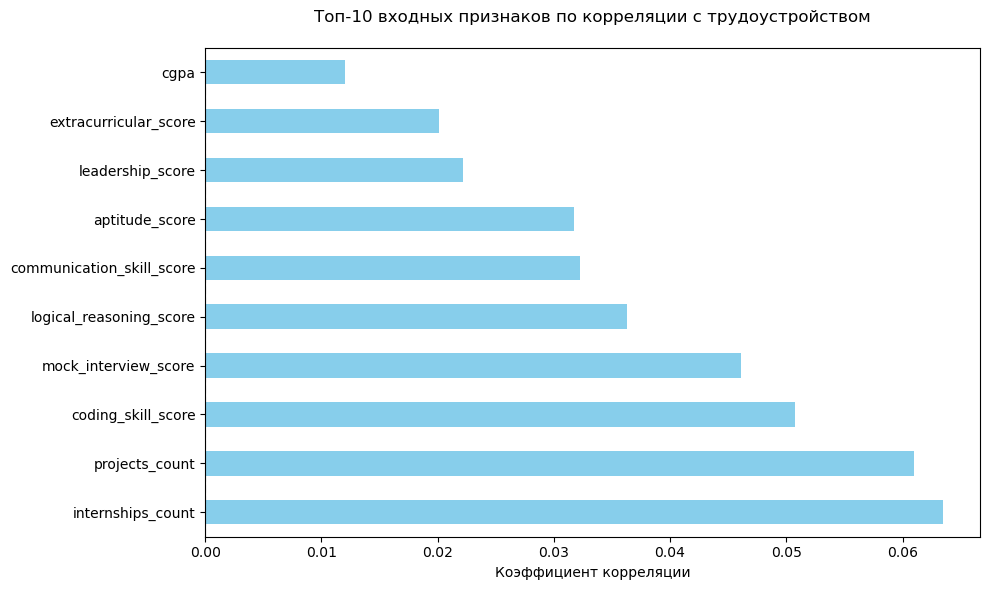

In [26]:
# КОРРЕЛЯЦИЯ ПРИЗНАКОВ С ТРУДОУСТРОЙСТВОМ

target = 'placement_status_encoded'

exclude_cols = ['placement_status_encoded', 'salary_package_lpa']

features_df = numeric_df.drop(columns=exclude_cols, errors='ignore')
correlations = features_df.corrwith(numeric_df[target]).sort_values(ascending=False)

print("Корреляция входных признаков с трудоустройством (по убыванию):")
print(correlations)

plt.figure(figsize=(10, 6))
correlations.head(10).plot(kind='barh', color='skyblue')
plt.title('Топ-10 входных признаков по корреляции с трудоустройством\n')
plt.xlabel('Коэффициент корреляции')
plt.axvline(0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()

Корреляция входных признаков с зарплатой (по убыванию):
internships_count               0.063489
projects_count                  0.060964
coding_skill_score              0.050773
mock_interview_score            0.046058
logical_reasoning_score         0.036332
communication_skill_score       0.032242
aptitude_score                  0.031690
leadership_score                0.022170
extracurricular_score           0.020100
cgpa                            0.012067
github_repos                    0.004807
linkedin_connections            0.003223
college_tier_encoded            0.002005
gender_encoded                  0.001244
volunteer_experience_encoded    0.001240
hackathons_participated         0.001236
age                             0.000858
student_id                     -0.000821
study_hours_per_day            -0.001426
certifications_count           -0.003806
branch_encoded                 -0.004320
sleep_hours                    -0.004692
attendance_percentage          -0.008350
b

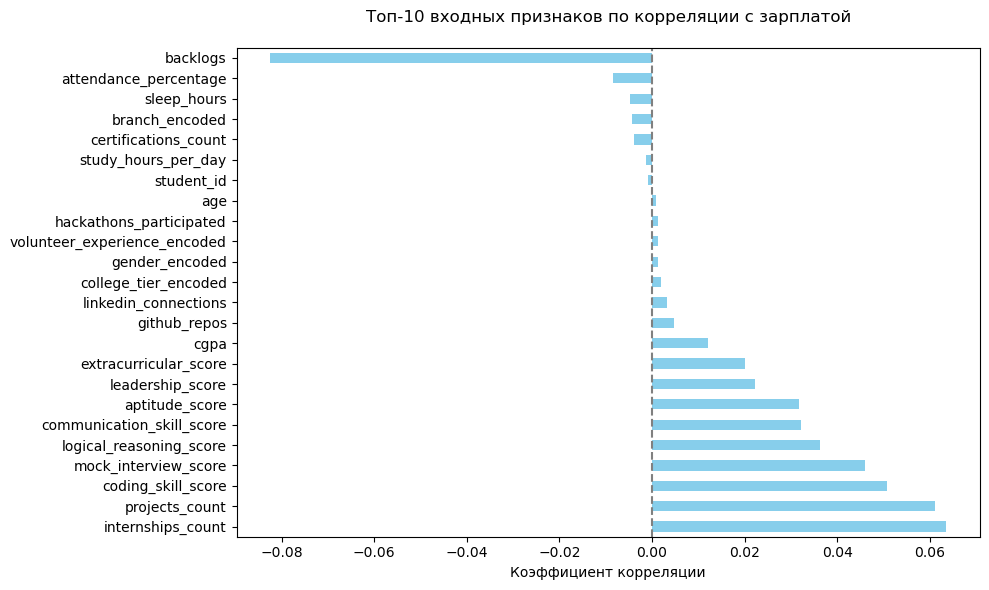

In [27]:
# КОРРЕЛЯЦИЯ ПРИЗНАКОВ С ЗАРПЛАТОЙ

target = 'placement_status_encoded'

exclude_cols = ['salary_package_lpa', 'salary_package_lpa', 'placement_status_encoded']

features_df = numeric_df.drop(columns=exclude_cols, errors='ignore')
correlations = features_df.corrwith(numeric_df[target]).sort_values(ascending=False)

print("Корреляция входных признаков с зарплатой (по убыванию):")
print(correlations)

plt.figure(figsize=(10, 6))
correlations.head(50).plot(kind='barh', color='skyblue')
plt.title('Топ-10 входных признаков по корреляции с зарплатой\n')
plt.xlabel('Коэффициент корреляции')
plt.axvline(0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()

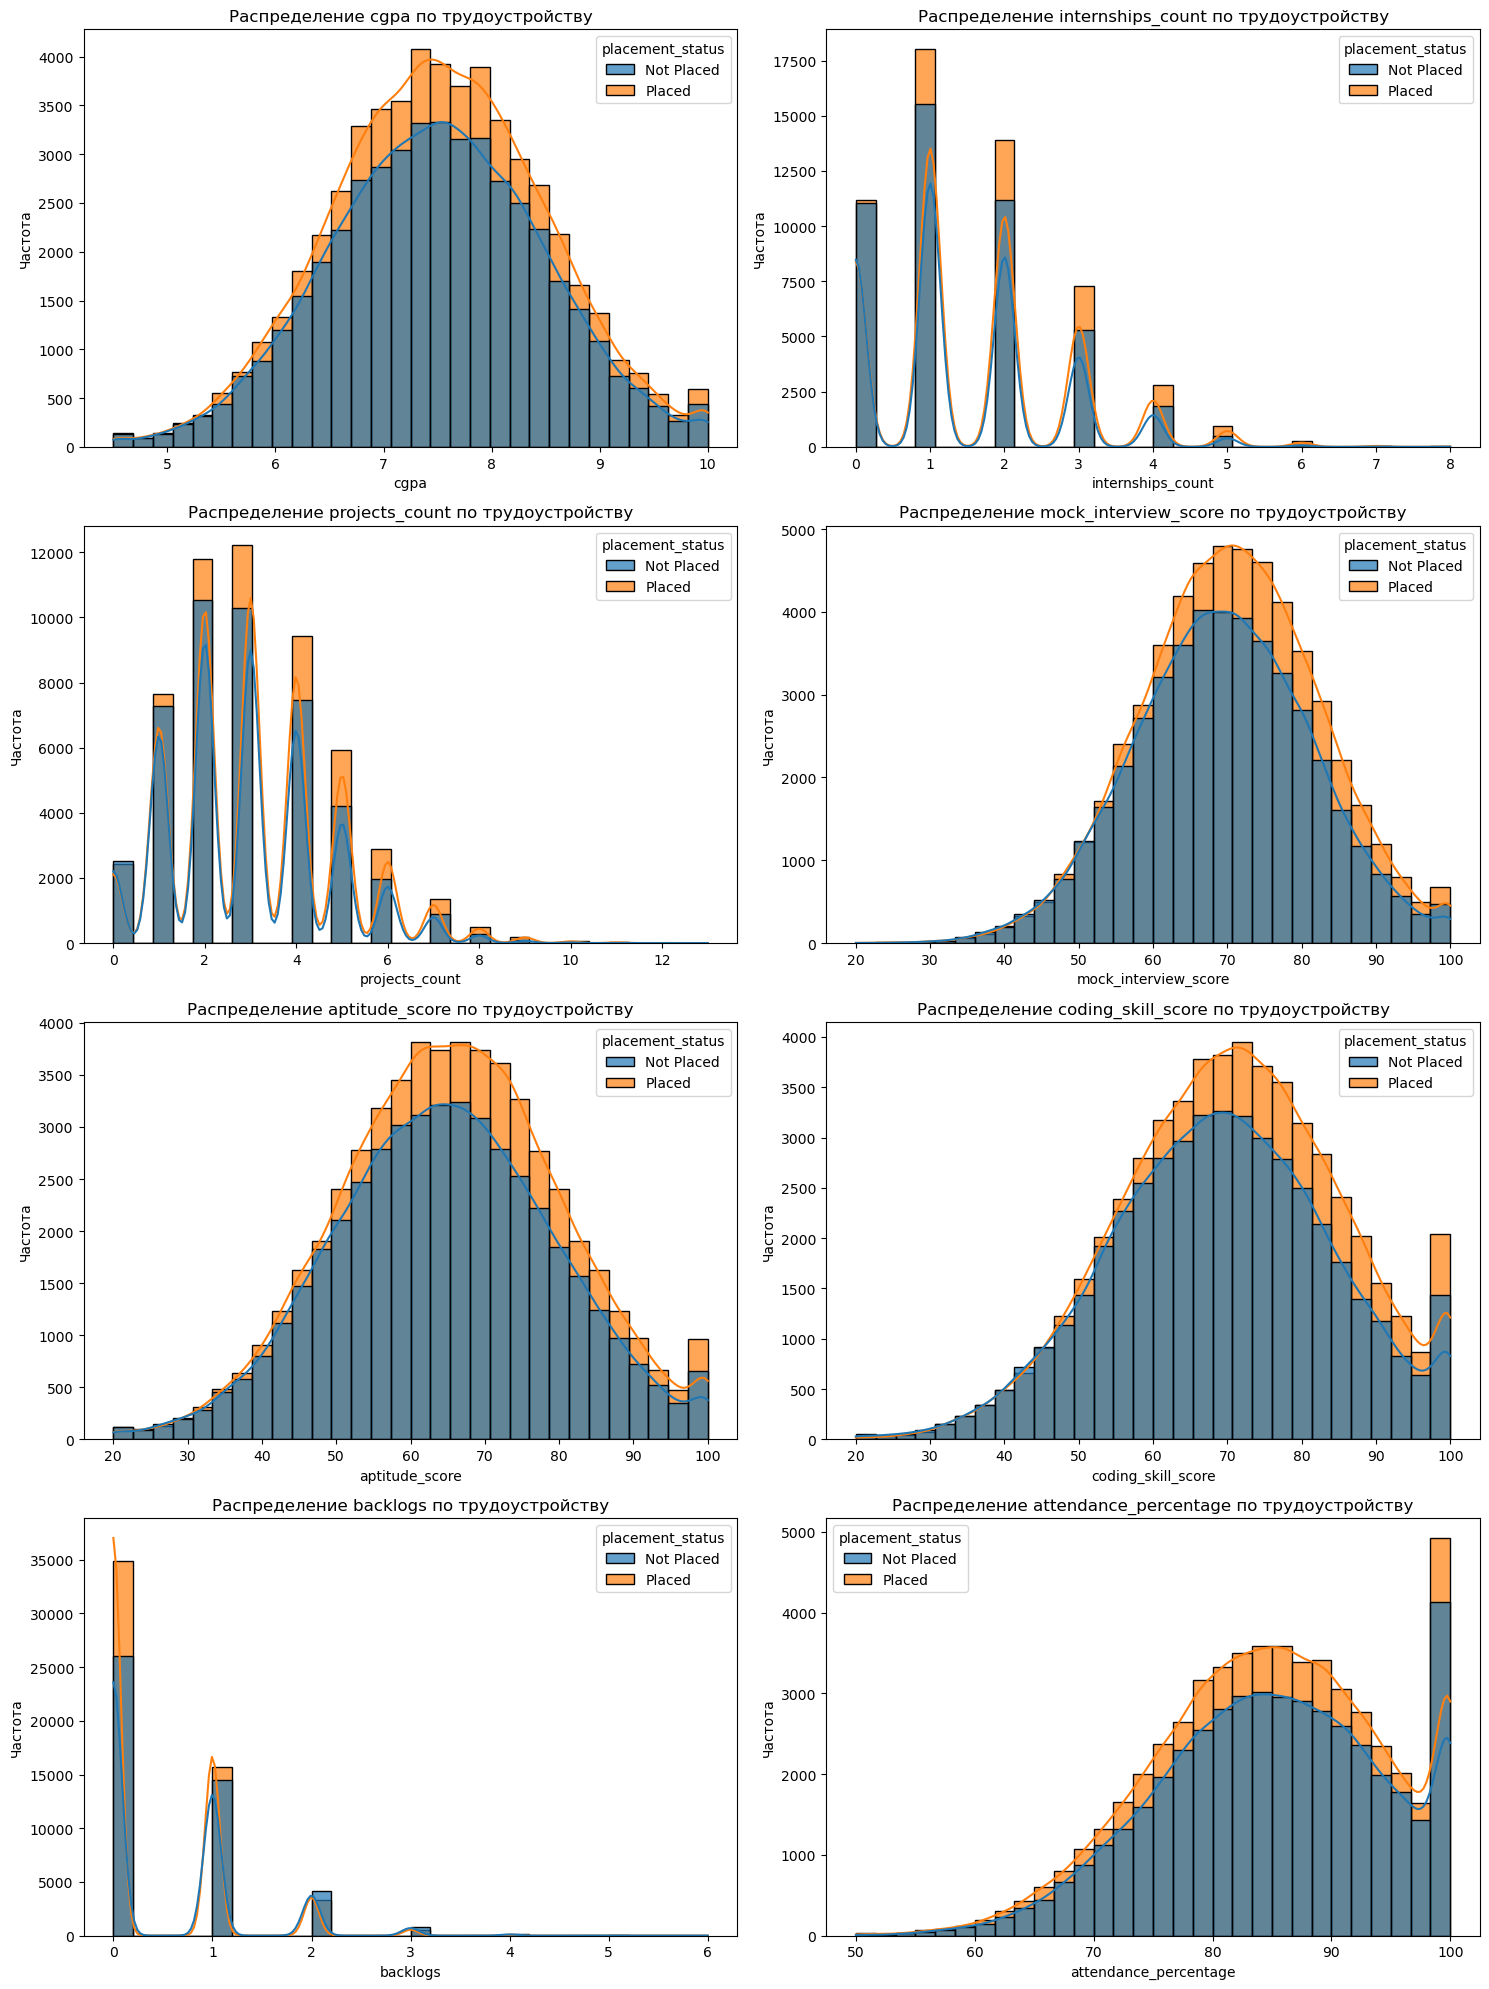

In [28]:
# ГРАФИКИ РАСПРЕДЕЛЕНИЯ ПРИЗНАКОВ

important_features = ['cgpa', 'internships_count', 'projects_count', 'mock_interview_score',
                      'aptitude_score', 'coding_skill_score', 'backlogs', 'attendance_percentage']

plt.figure(figsize=(15, 20))

for i, feature in enumerate(important_features, 1):
    plt.subplot(4, 2, i)
    sns.histplot(data=df, x=feature, hue='placement_status', kde=True, bins=30, alpha=0.7)
    plt.title(f'Распределение {feature} по трудоустройству')
    plt.xlabel(feature)
    plt.ylabel('Частота')

plt.tight_layout()
plt.show()

Трудоустраиваются те, кто хорошо учится, делает проекты, а также **БОЛЬШЕ** ходит по собесам и лучше кодит

4. Определить целевые векторы для решения на выбранном датасете задачи регрессионного анализа. Произвести предварительную подготовку данных для обучения, включающую:

* удаление информационных выбросов;
* исключение противоречий;
* исключение некорректных значений;
* обработку пропусков.

Основным вектором для задачи регрессии будет зарплата трудоустроенных студентов

In [30]:
df_placed = df[df['placement_status'] == 'Placed'].copy()
y_reg = df_placed['salary_package_lpa']

print("Размер выборки для регрессии:", df_placed.shape)
print("Средняя зарплата среди Placed: {:.2f} LPA".format(y_reg.mean()))
print("Медианная зарплата среди Placed: {:.2f} LPA".format(y_reg.median()))

Размер выборки для регрессии: (54459, 31)
Средняя зарплата среди Placed: 13.32 LPA
Медианная зарплата среди Placed: 13.30 LPA


Предобработка

In [32]:
print("Пропусков:", df.isna().sum().sum())

df_clean = df.copy()

# Ограничиваем диапазоны
df_clean = df_clean[
    (df_clean['cgpa'].between(4.0, 10.0)) &
    (df_clean['age'].between(17, 25)) &
    (df_clean['attendance_percentage'].between(30, 100)) &
    (df_clean['backlogs'] <= 8)
]

score_cols = [
    'coding_skill_score', 'aptitude_score', 'communication_skill_score',
    'logical_reasoning_score', 'mock_interview_score'
]
for col in score_cols:
    df_clean[col] = df_clean[col].clip(0, 100)

print("Размер после фильтрации некорректных значений:", df_clean.shape)

Пропусков: 0
Размер после фильтрации некорректных значений: (100000, 31)


In [33]:
# Базовые статистики по числовым признакам
print("\nЧисловые признаки:")
print(df.describe(include='number').T)


Числовые признаки:
                                 count          mean           std   min  \
student_id                    100000.0  50000.500000  28867.657797   1.0   
age                           100000.0     21.005740      1.999562  18.0   
cgpa                          100000.0      7.496890      0.992834   4.5   
internships_count             100000.0      1.502230      1.225280   0.0   
projects_count                100000.0      3.001860      1.731764   0.0   
certifications_count          100000.0      2.005150      1.416553   0.0   
coding_skill_score            100000.0     69.825326     14.694618  20.0   
aptitude_score                100000.0     64.988108     14.844093  20.0   
communication_skill_score     100000.0     67.960744     13.846636  20.0   
logical_reasoning_score       100000.0     65.931696     14.826790  20.0   
hackathons_participated       100000.0      1.000690      0.997908   0.0   
github_repos                  100000.0      4.005160      2.004897  

In [34]:
# Удаляем строки с пропусками
df_clean = df.dropna().copy()
print(f"Размер до удаления NaN: {df.shape}, после: {df_clean.shape}")

Размер до удаления NaN: (100000, 31), после: (100000, 31)


Удаление информационных выбросов

In [35]:
df_reg = df_clean[df_clean['placement_status'] == 'Placed'].copy()


lower = df_reg['salary_package_lpa'].quantile(0.005)
upper = df_reg['salary_package_lpa'].quantile(0.995)

print(f"Удаляем зарплаты < {lower:.2f} и > {upper:.2f} LPA")

df_reg = df_reg[
    df_reg['salary_package_lpa'].between(lower, upper)
]

print("Размер после удаления выбросов по зарплате:", df_reg.shape)

Удаляем зарплаты < 9.32 и > 17.39 LPA
Размер после удаления выбросов по зарплате: (53917, 31)


Работа с противоречиями

In [37]:
# не может быть трудостроуен с зарплатой = 0
contradict = df[(df['placement_status'] == 'Placed') & (df['salary_package_lpa'] == 0)]
print("Трудостроуен с зарплатой = 0:", len(contradict))

# Не может быть устроенным, но с зарплатой > 0
contradict2 = df[(df['placement_status'] == 'Not Placed') & (df['salary_package_lpa'] > 0)]
print("Устроен, но зарплата > 0:", len(contradict2))


df_clean = df_clean[
    ~((df_clean['placement_status'] == 'Placed') & (df_clean['salary_package_lpa'] == 0)) &
    ~((df_clean['placement_status'] == 'Not Placed') & (df_clean['salary_package_lpa'] > 0))
]

Трудостроуен с зарплатой = 0: 0
Устроен, но зарплата > 0: 0


5.	Определить целевые векторы для решения на выбранном датасете задачи регрессионного анализа. Произвести предварительную подготовку  данных для обучения, включающую:
* поиск и замену неявных дубликатов;
* нормализацию данных датасета.
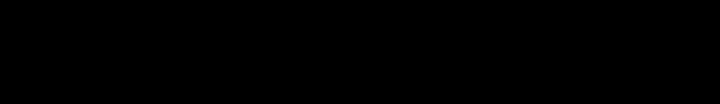

In [39]:
# Проверка полных дубликатов

duplicates_full = df.duplicated().sum()
print(f"Полных одинаковых строк: {duplicates_full}")

if duplicates_full > 0:
    df = df.drop_duplicates()
    print("Удалено полных дубликатов строк")

Полных одинаковых строк: 0


In [40]:
# Проверка дубликатов с одинаковыми базовыми значениями

key_cols = ['student_id', 'age', 'gender', 'cgpa', 'branch', 'college_tier']

dups_key = df.duplicated(subset=key_cols, keep=False)
print(f"Записей, которые дублируются по ключевым полям: {dups_key.sum()}")

if dups_key.sum() > 0:
    print("Примеры дубликатов:")
    print(df[dups_key].sort_values(key_cols).head(6))

    # Самый простой и безопасный вариант — оставить первую запись
    df = df.drop_duplicates(subset=key_cols, keep='first')
    print(f"После удаления: {df.shape}")

Записей, которые дублируются по ключевым полям: 0


In [41]:
# Проверка неявных дубликатов в категориях (опечатки, регистр)

cat_cols = ['gender', 'branch', 'college_tier', 'volunteer_experience', 'placement_status']

for col in cat_cols:
    unique = df[col].astype(str).str.lower().str.strip().value_counts()
    print(f"\n{col} (приведено к нижнему регистру и очищено):")
    print(unique)


gender (приведено к нижнему регистру и очищено):
gender
male      60028
female    39972
Name: count, dtype: int64

branch (приведено к нижнему регистру и очищено):
branch
cse           34818
it            19999
ece           14908
eee           10177
mechanical    10077
civil         10021
Name: count, dtype: int64

college_tier (приведено к нижнему регистру и очищено):
college_tier
tier 2    49955
tier 3    29884
tier 1    20161
Name: count, dtype: int64

volunteer_experience (приведено к нижнему регистру и очищено):
volunteer_experience
no     59963
yes    40037
Name: count, dtype: int64

placement_status (приведено к нижнему регистру и очищено):
placement_status
placed        54459
not placed    45541
Name: count, dtype: int64


Нормализация

In [45]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# числовые признаки, которые будем нормализовать
# исключаем: student_id, целевые переменные
features_to_scale = [
    'age', 'cgpa', 'internships_count', 'projects_count', 'certifications_count',
    'coding_skill_score', 'aptitude_score', 'communication_skill_score',
    'logical_reasoning_score', 'hackathons_participated', 'github_repos',
    'linkedin_connections', 'mock_interview_score', 'attendance_percentage',
    'backlogs', 'extracurricular_score', 'leadership_score',
    'sleep_hours', 'study_hours_per_day'
]

# Целевой вектор для регресии
df_reg = df[df['placement_status'] == 'Placed'].copy()

# MinMaxScaler [0,1]
scaler_mm = MinMaxScaler()
df_reg[features_to_scale] = scaler_mm.fit_transform(df_reg[features_to_scale])

# StandardScaler (среднее 0, std 1)
# scaler_ss = StandardScaler()
# df_reg[features_to_scale] = scaler_ss.fit_transform(df_reg[features_to_scale])

print("После нормализации (первые 3 строки):")
print(df_reg[features_to_scale].head(3))



После нормализации (первые 3 строки):
        age      cgpa  internships_count  projects_count  \
2  0.666667  0.745455              0.000        0.076923   
4  0.333333  0.714545              0.125        0.307692   
5  0.666667  0.534545              0.125        0.384615   

   certifications_count  coding_skill_score  aptitude_score  \
2              0.090909            0.364715        0.358234   
4              0.272727            0.562732        0.515937   
5              0.090909            0.371986        0.315657   

   communication_skill_score  logical_reasoning_score  \
2                   0.901311                 0.757542   
4                   0.861954                 0.452046   
5                   0.398522                 0.624807   

   hackathons_participated  github_repos  linkedin_connections  \
2                 0.000000         0.125              0.545838   
4                 0.142857         0.250              0.825079   
5                 0.428571         0.500 

In [46]:
print("После нормализации — min и max по всем признакам:")
print(df_reg[features_to_scale].min().round(4))
print("\n")
print(df_reg[features_to_scale].max().round(4))

После нормализации — min и max по всем признакам:
age                          0.0
cgpa                         0.0
internships_count            0.0
projects_count               0.0
certifications_count         0.0
coding_skill_score           0.0
aptitude_score               0.0
communication_skill_score    0.0
logical_reasoning_score      0.0
hackathons_participated      0.0
github_repos                 0.0
linkedin_connections         0.0
mock_interview_score         0.0
attendance_percentage        0.0
backlogs                     0.0
extracurricular_score        0.0
leadership_score             0.0
sleep_hours                  0.0
study_hours_per_day          0.0
dtype: float64


age                          1.0
cgpa                         1.0
internships_count            1.0
projects_count               1.0
certifications_count         1.0
coding_skill_score           1.0
aptitude_score               1.0
communication_skill_score    1.0
logical_reasoning_score      1.0
hackathon